# Tutorial 2: Fidelity levels and convergence

AEGIS organises its physics models into nine fidelity levels (0-8). Higher levels
add physics corrections at increasing computational cost. This tutorial shows how
each level affects computed $S_{\mathrm{ab}}$, how to run a convergence sweep, and
how many paths you need for a stable estimate.

## The three-tier hierarchy

The nine levels fall into three tiers based on what they compute and at what cost.

| Tier | Levels | Cost | Output |
|------|--------|------|--------|
| Bound | 0 | $O(1)$ | Scalar $P_{\mathrm{abs}}$ upper bound, uniform $S_{\mathrm{ab}}$ |
| Aggregate | 1 | $O(N)$ | Scalar $P_{\mathrm{abs}}$ weighted by directivity, uniform $S_{\mathrm{ab}}$ |
| Spatial | 2-6 | $O(MN)$ | Per-triangle $S_{\mathrm{ab}}(\mathbf{r})$ map with progressive corrections |
| Coherent | 7-8 | $O(M \cdot M_{\mathrm{ant}}^2)$ | Per-triangle $S_{\mathrm{ab}}$ from complex field superposition |

$M$ = number of body triangles, $N$ = number of propagation paths,
$M_{\mathrm{ant}}$ = number of antenna elements.

Levels 0 and 1 require precomputed antenna parameters ($A_{\mathrm{ab}}$ and
$D_{\mathrm{max}}$) that are not always available. Levels 2-6 need only the body
mesh, tissue model, and a set of propagation paths. Coherent levels 7-8 require
per-path complex amplitudes and are covered in Tutorial 5.

## Spatial levels 2-6 in detail

Each level adds one physical correction on top of the previous one.

| Level | Correction added | Key equation |
|-------|-----------------|-------------|
| 2 | Geometric ReLU with constant $T_0$ | $S_{\mathrm{ab}} = T_0 \cdot [\hat{n} \cdot (-\hat{k})]_+ \cdot S_{\mathrm{inc}}$ |
| 3 | Angle-dependent Fresnel $T(\theta_i)$ | $T_0 \to T_{\mathrm{avg}}(\theta_i)$ |
| 4 | Polarisation correction | $T_{\mathrm{avg}} \to T_{\mathrm{avg}} + \tfrac{q}{2} \Delta T$ |
| 5 | Surface curvature (Physical Optics) | adds $T_0 \cdot \frac{H}{k} \cdot g(\mu)^2 \cdot S_{\mathrm{inc}}$ |
| 6 | Diffraction smoothing | replaces ReLU with GELU at shadow boundaries |

Level 3 is the default when you call `engine.compute(body, paths, mode="spatial")`.
The Fresnel correction alone reduces the error from a constant-$T_0$ assumption by
roughly 5.6% for skin at 28 GHz.

## Setup

These imports and helpers are shared across all code blocks in this tutorial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401
plt.style.use(["science", "ieee", "no-latex"])
plt.rcParams.update({"figure.figsize": (3.5, 2.625)})

from aegis.engine import DosimetryEngine
from aegis.geometry.mesh import BodyMesh
from aegis.paths import PropagationPaths
from aegis.tissue.dielectric import SKIN_28GHZ

# Icosahedron: 20 triangles, 10 cm radius, outward normals
phi = (1 + np.sqrt(5)) / 2
verts_raw = np.array([
    [-1, phi, 0], [1, phi, 0], [-1, -phi, 0], [1, -phi, 0],
    [0, -1, phi], [0, 1, phi], [0, -1, -phi], [0, 1, -phi],
    [phi, 0, -1], [phi, 0, 1], [-phi, 0, -1], [-phi, 0, 1],
], dtype=float)
verts_raw /= np.linalg.norm(verts_raw[0])
verts_raw *= 0.1  # 10 cm radius

faces = [
    (0,11,5),(0,5,1),(0,1,7),(0,7,10),(0,10,11),
    (1,5,9),(5,11,4),(11,10,2),(10,7,6),(7,1,8),
    (3,9,4),(3,4,2),(3,2,6),(3,6,8),(3,8,9),
    (4,9,5),(2,4,11),(6,2,10),(8,6,7),(9,8,1),
]
n_tri = len(faces)
vertices = np.zeros((n_tri, 3, 3))
for i, (a, b, c) in enumerate(faces):
    vertices[i] = [verts_raw[a], verts_raw[b], verts_raw[c]]

v0, v1, v2 = vertices[:, 0], vertices[:, 1], vertices[:, 2]
cross = np.cross(v1 - v0, v2 - v0)
lens = np.linalg.norm(cross, axis=1, keepdims=True)
normals = cross / lens
centroids = vertices.mean(axis=1)
# Flip inward-pointing normals
flip = np.einsum("ij,ij->i", normals, centroids) < 0
normals[flip] *= -1
areas = 0.5 * lens[:, 0]

body = BodyMesh(
    vertices=vertices,
    normals=normals,
    centroids=centroids,
    areas=areas,
    name="icosahedron",
)

# 50 random paths, uniform directions, equal power
rng = np.random.default_rng(42)
N = 50
k_hat = rng.standard_normal((N, 3))
k_hat /= np.linalg.norm(k_hat, axis=1, keepdims=True)
power = np.ones(N) * 10.0  # 10 W/m^2 each

paths = PropagationPaths.from_powers(k_hat=k_hat, power=power)

engine = DosimetryEngine(SKIN_28GHZ)

## Level 2 baseline

Level 2 uses the geometric ReLU with the constant normal-incidence transmission
coefficient $T_0$.

$$S_{\mathrm{ab}}(\mathbf{r}) = T_0 \cdot \sum_{n=1}^{N} [\hat{n}(\mathbf{r}) \cdot (-\hat{k}_n)]_+ \cdot S_n$$

In [2]:
result2 = engine.compute(body, paths, level=2)

print(f"Level 2  P_abs = {result2.p_abs:.4f} W")
print(f"         T0    = {SKIN_28GHZ.T0:.4f}")
print(f"         S_ab  mean = {result2.sab.mean():.4f} W/m^2")
print(f"         S_ab  max  = {result2.sab.max():.4f} W/m^2")

Level 2  P_abs = 6.4559 W
         T0    = 0.5387
         S_ab  mean = 67.4274 W/m^2
         S_ab  max  = 85.5583 W/m^2


The output confirms that some triangles receive no power (shadowed faces where
$\hat{n} \cdot (-\hat{k}) \le 0$) and illuminated faces get a cosine-weighted sum.

## Level 3: angle-dependent Fresnel

Level 3 replaces $T_0$ with the angle-averaged Fresnel transmission
$T_{\mathrm{avg}}(\theta_i)$, evaluated at the angle of incidence for each path.
The difference is significant near grazing angles where $T_{\mathrm{avg}}$ rises
above $T_0$ due to the TM pseudo-Brewster effect.

In [3]:
result3 = engine.compute(body, paths, level=3)

print(f"Level 3  P_abs = {result3.p_abs:.4f} W")
delta = (result3.p_abs - result2.p_abs) / result2.p_abs * 100
print(f"         change from level 2: {delta:+.2f}%")

Level 3  P_abs = 6.5337 W
         change from level 2: +1.21%


For skin at 28 GHz with isotropic paths the correction is typically a few percent.
In scenarios with predominantly grazing arrivals it can exceed 10%.

## Sweep all incoherent levels

`sweep_levels` runs all specified levels in one call and returns a dict mapping
level to result. Levels 0 and 1 require `A_ab` and `D_max`; if those are not
provided, `sweep_levels` silently skips those levels.

In [4]:
# Levels 2-6 need no extra parameters for this synthetic example
results = engine.sweep_levels(body, paths, levels=[2, 3, 4, 5, 6])

print(f"{'Level':>6}  {'P_abs (W)':>12}  {'S_ab mean (W/m^2)':>18}  {'S_ab max (W/m^2)':>17}")
print("-" * 62)
for lvl, res in sorted(results.items()):
    print(f"{lvl:>6}  {res.p_abs:>12.5f}  {res.sab.mean():>18.5f}  {res.sab.max():>17.5f}")

 Level     P_abs (W)   S_ab mean (W/m^2)   S_ab max (W/m^2)
--------------------------------------------------------------
     2       6.45586            67.42739           85.55830
     3       6.53368            68.24011           86.46366
     4       6.53368            68.24011           86.46366
     5       6.53368            68.24011           86.46366
     6       6.53368            68.24011           86.46366


To include levels 0 and 1 you need antenna parameters from a body-specific
calculation (see Tutorial 4). Providing them is straightforward:

In [5]:
# Example with antenna parameters (replace with actual values)
A_ab = 1.2e-3   # absorption area in m^2
D_max = 3.0     # maximum directivity (dimensionless)

results_all = engine.sweep_levels(
    body, paths,
    levels=[0, 1, 2, 3, 4, 5, 6],
    A_ab=A_ab,
    D_max=D_max,
)

## Mode-based API

The mode API makes the corrections explicit without memorising level numbers.
All combinations below are equivalent to the corresponding integer levels.

In [6]:
# Level 2: spatial kernel, no Fresnel
r = engine.compute(body, paths, mode="spatial", fresnel=False)

# Level 3: spatial kernel with Fresnel (default when mode="spatial")
r = engine.compute(body, paths, mode="spatial")
r = engine.compute(body, paths, mode="spatial", fresnel=True)  # same

# Level 4: add polarisation correction (requires per-path TM excess q)
q = rng.uniform(-1, 1, size=N)   # TM excess in [-1, 1] per path
r = engine.compute(body, paths, mode="spatial", polarisation=True, q=q)

# Level 5: curvature correction (requires per-triangle twice-mean curvature H)
H = np.zeros(body.n_triangles)   # flat approximation: H = 0
r = engine.compute(body, paths, mode="spatial", curvature=True, curvature_H=H)

# Level 6: diffraction smoothing (enables curvature implicitly)
r = engine.compute(body, paths, mode="spatial", diffraction=True, curvature_H=H)

The mode API is preferable when you want composable corrections without coupling
to the integer level numbering. `result.fidelity_level` and `result.corrections`
record what was actually computed.

## Multipath convergence

The incoherent absorbed power density converges as paths are added. For $N$
independent paths the standard error of the mean decays as $1/\sqrt{N}$. The
Cauchy convergence criterion compares consecutive estimates:

$$\Delta_N = |P_{\mathrm{abs}}(N) - P_{\mathrm{abs}}(N-1)|$$

In [7]:
n_values = [5, 10, 20, 50, 100, 200, 500]
p_abs_values = []

# Generate a large pool of paths; subsample for each N
rng2 = np.random.default_rng(0)
N_max = max(n_values)
k_pool = rng2.standard_normal((N_max, 3))
k_pool /= np.linalg.norm(k_pool, axis=1, keepdims=True)
p_pool = np.ones(N_max) * 10.0

for n in n_values:
    paths_n = PropagationPaths.from_powers(k_hat=k_pool[:n], power=p_pool[:n])
    res = engine.compute(body, paths_n, level=3)
    p_abs_values.append(res.p_abs)

p_ref = p_abs_values[-1]  # use N=500 as reference
errors = [abs(p - p_ref) / p_ref * 100 for p in p_abs_values]

print(f"{'N':>6}  {'P_abs (W)':>12}  {'Error vs N=500 (%)':>20}")
print("-" * 44)
for n, p, e in zip(n_values, p_abs_values, errors):
    print(f"{n:>6}  {p:>12.5f}  {e:>20.3f}")

     N     P_abs (W)    Error vs N=500 (%)
--------------------------------------------
     5       0.66007                98.990
    10       1.30667                98.001
    20       2.61185                96.004
    50       6.50142                90.052
   100      13.07752                79.990
   200      26.14429                59.996
   500      65.35376                 0.000


Plot the convergence curve:

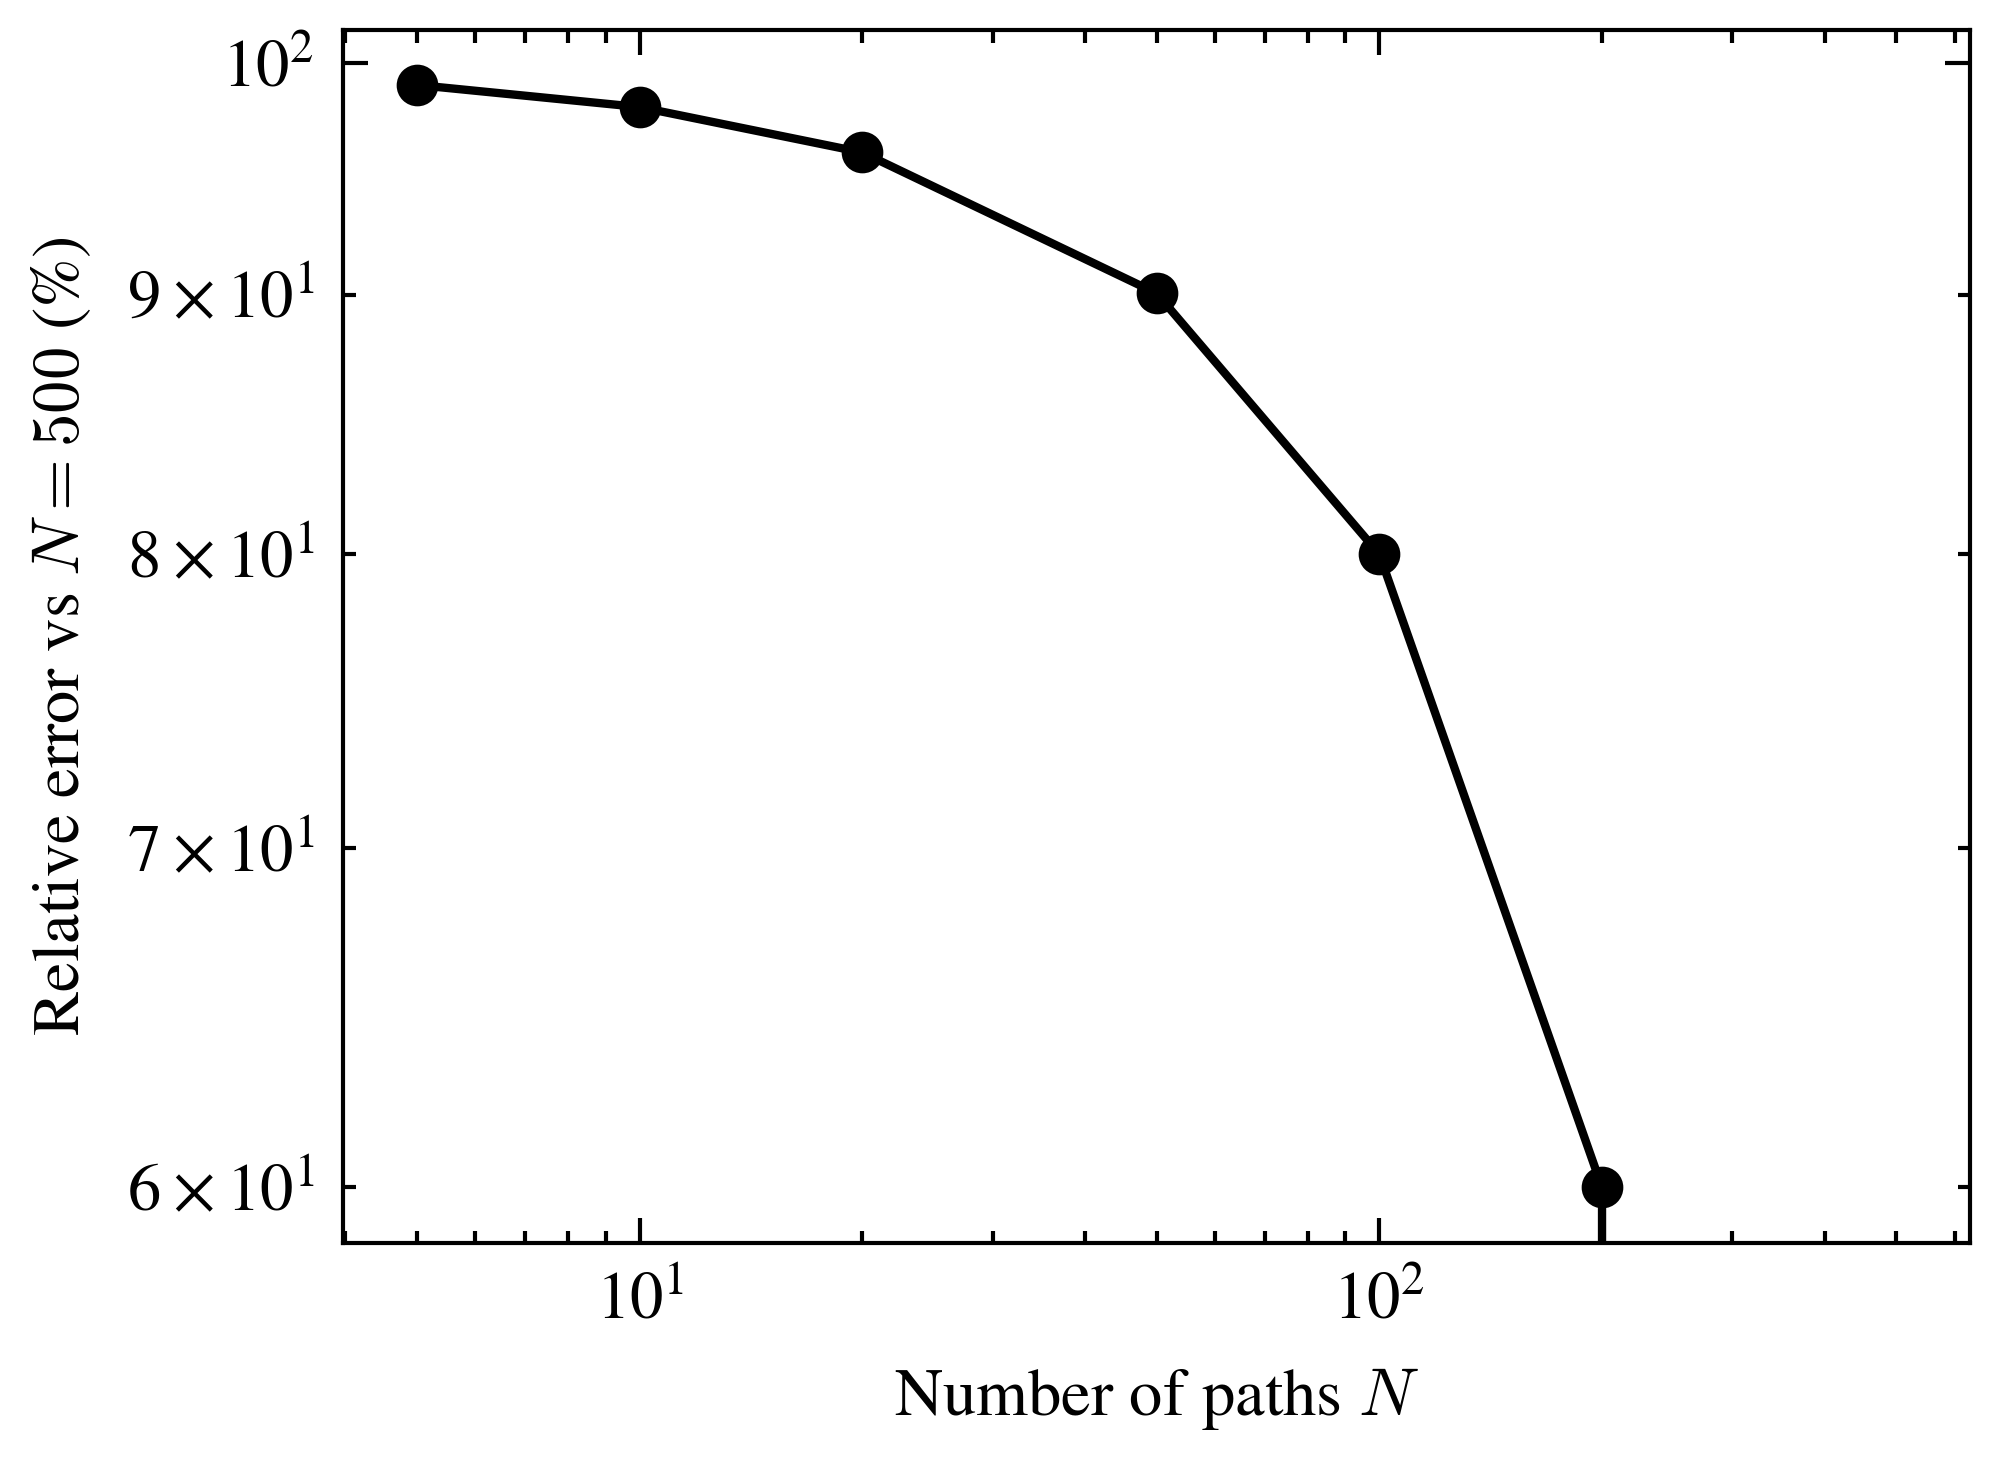

In [8]:
fig, ax = plt.subplots()
ax.loglog(n_values, errors, "o-", markersize=4)
ax.set_xlabel("Number of paths $N$")
ax.set_ylabel(r"Relative error vs $N{=}500$ (%)")
plt.show()

For a uniform isotropic channel on a convex body, about 50 paths are enough to
reach 1% accuracy at level 3. More paths are needed when the channel has strong
directional structure or when you compute higher-order statistics.

!!! tip
    The Cauchy criterion is conservative. If your scenario has a dominant
    line-of-sight path, even $N = 10$ may give a stable total power estimate,
    though the per-triangle spatial map will still be noisy.

## Next steps

- **Tutorial 3**: [Tissue physics and Fresnel transmission](tissue_and_fresnel.md) -- Cole-Cole model, pseudo-Brewster compensation, angle-dependent $T(\theta)$
- **Tutorial 4**: [ICNIRP 2020 compliance](compliance.md) -- regulatory limits, power sweeps, how to get $A_{\mathrm{ab}}$ and $D_{\mathrm{max}}$
- **Tutorial 5**: [Coherent MIMO and ECBF](coherent_mimo.md) -- complex amplitudes, exposure operator $\mathbf{Q}$, exposure-constrained beamforming